##  BÀI TẬP 2.4
#### **Họ và tên:** Nguyễn Quang Linh  
#### **MSSV:** 038205003016

### 1. Nạp dự liệu wine datasets vào bộ nhớ và hiển thị thông tin về số thuộc tính (dimensionality), số objects (size).

In [ ]:
from sklearn.datasets import load_wine

wine_data = load_wine()
X = wine_data.data 
Y = wine_data.target

n_samples, n_features = X.shape 
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")


Number of samples: 178
Number of features: 13


### 2. Đặt nhãn (label) cho dữ liệu đã nạp và hiển thị số lớp (classes)

In [2]:
print(f"Set labels for target variable {wine_data.target_names}")
print(f"Number of classes: {len(wine_data.target_names)}")

Set labels for target variable ['class_0' 'class_1' 'class_2']
Number of classes: 3


### 3. Tách dữ liệu thành hai phần: training data(70%) và test data (30%)

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
  X,Y, test_size = 0.3, random_state = 42
)
print(f"Size of training set: {X_train.shape[0]} samples")
print(f"Size of training set: {X_test.shape[0]} samples")



Size of training set: 124 samples
Size of training set: 54 samples


### 4. Chuẩn hóa dữ liệu với StandardScaler

In [4]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 5. Tạo và huấn luyện mô hình với training data

In [6]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion="gini", random_state=42)
clf.fit(X_train,Y_train)
depth = clf.get_depth()
print(f"Done successfully training the model.")


Done successfully training the model.


### 6. Đánh giá mô hình (Evaluation)  confusion matrix, accuracy, f-score

Accuracy: 0.96
F1-score: 0.96
Confusion Matrix:
[[18  1  0]
 [ 0 21  0]
 [ 1  0 13]]
Heatmap visualization of the confusion matrix


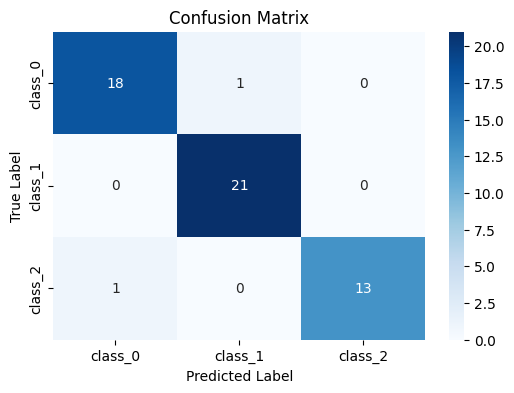

In [8]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt 

Y_predict = clf.predict(X_test)
accuracy = accuracy_score(Y_test, Y_predict)
print(f"Accuracy: {accuracy:.2f}")
f1 = f1_score(Y_test, Y_predict, average='macro')
print(f"F1-score: {f1:.2f}")
cm = confusion_matrix(Y_test, Y_predict)
print(f"Confusion Matrix:\n{cm}")

print(f"Heatmap visualization of the confusion matrix")
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=wine_data.target_names, yticklabels=wine_data.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### 7. Trực quan hóa cây quyết định

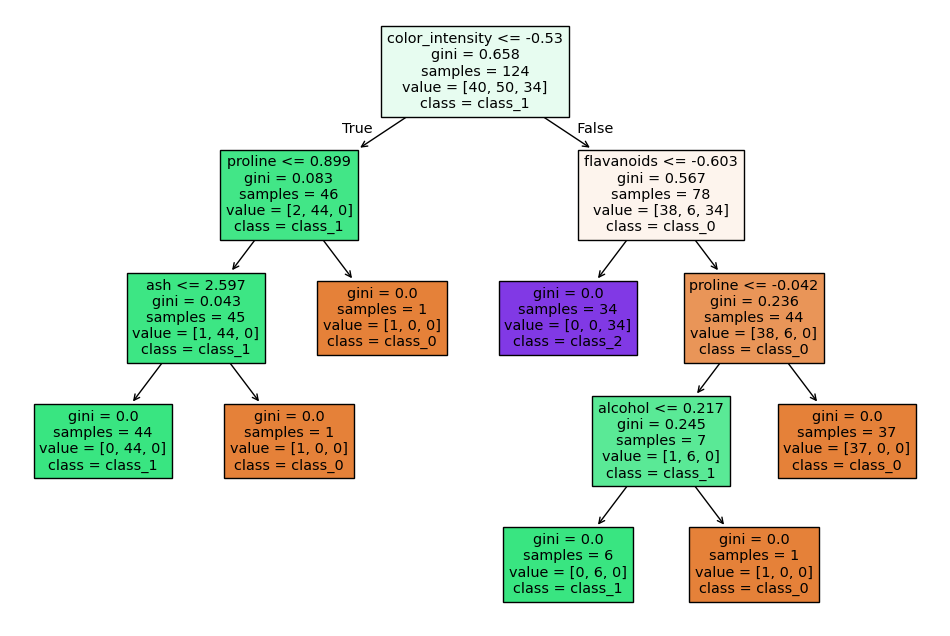

In [9]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(clf, filled=True, feature_names=wine_data.feature_names, class_names=wine_data.target_names)
plt.show()